<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Problema03_U4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [ ]:
import pandas as pd
from io import StringIO

datos = """
tratamiento,tiempo
A,213
B,76
C,57
D,84
A,214
B,85
C,67
D,82
A,204
B,74
C,55
D,85
A,208
B,78
C,64
D,92
A,212
B,82
C,61
D,87
A,200
B,75
C,63
D,79
A,207
B,82
C,63
D,90
"""

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,tratamiento,tiempo
0,A,213
1,B,76
2,C,57
3,D,84
4,A,214
5,B,85
6,C,67
7,D,82
8,A,204
9,B,74


In [ ]:
df.columns

Index(['tratamiento', 'tiempo'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('tiempo ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales

,sum_sq,df,F,PR(>F)
C(tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) =  0.3469


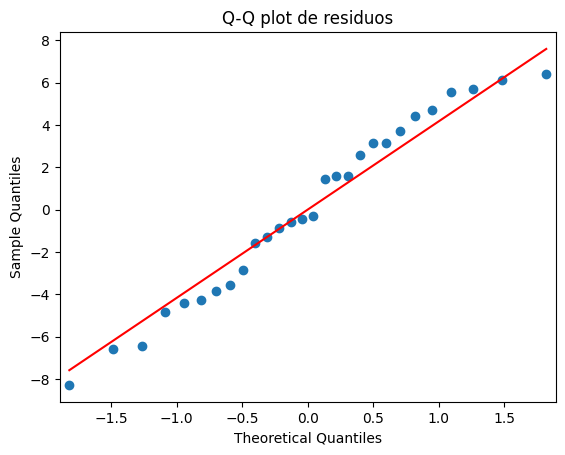

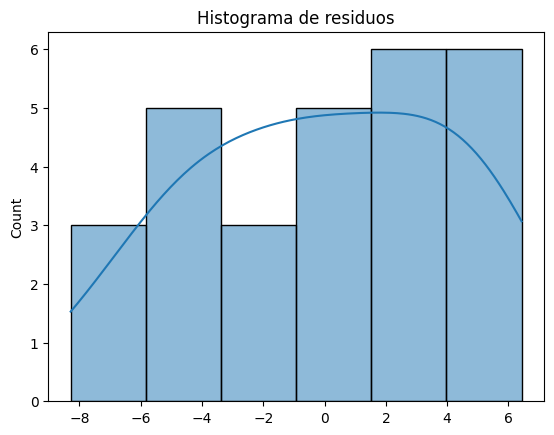

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh: 0.4f}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'A']['tiempo']
grupo_B = df[df['tratamiento'] == 'B']['tiempo']
grupo_C = df[df['tratamiento'] == 'C']['tiempo']
grupo_D = df[df['tratamiento'] == 'D']['tiempo']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1631
p-valor: 0.9201


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     A      B -129.4286    0.0 -136.0757 -122.7815   True
     A      C -146.8571    0.0 -153.5043   -140.21   True
     A      D -122.7143    0.0 -129.3614 -116.0672   True
     B      C  -17.4286    0.0  -24.0757  -10.7815   True
     B      D    6.7143 0.0471    0.0672   13.3614   True
     C      D   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

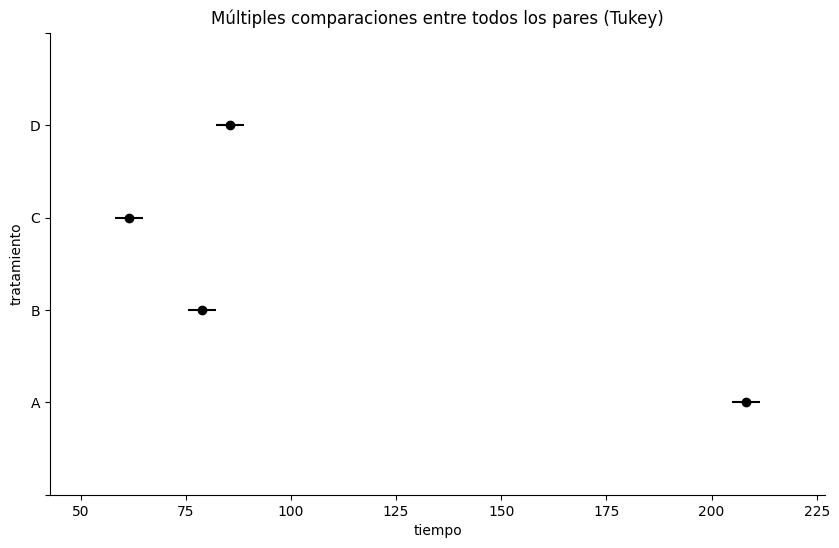

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['tiempo'], # Variable de respuesta
    groups=df['tratamiento'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tratamiento", xlabel="tiempo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["tratamiento"]).mean()["tiempo"]

,tiempo
tratamiento,
A,208.285714
B,78.857143
C,61.428571
D,85.571429


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.966


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9659
f de Cohen = 5.3259
Potencia de la prueba = 1.0000


Conclusión:

Según las pruebas del diseño experimental DCA el tratamiento más recomendable para reducir el tiempo de cocción es el 3, que es remojar con sal normal antes de cocerlos.
Haciendo el test de Shapiro nos da un valor de 0.3469
que nos indica que existe normalidad.
El test de Levene nos indica que el 92.01% de que en los 4 tratamientos si se encuentra homoscedasticidad.
Sin embargo, otra opcion buena que no tiene tanta diferencia significativa es el 2, que es remojarlos con bicarbonato de sodio.
Así que si se desea ahorro de tiempo los tratamientos 1 y 4 son los menos recomendados.